In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torchvision.transforms.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, classification_report, confusion_matrix
from scipy.stats import pearsonr
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
from torch.cuda.amp import autocast, GradScaler

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Constants
IMG_SIZE = 224
NUM_CLASSES = 8
EPOCHS = 50
PATIENCE = 7  # For early stopping
UNFREEZE_EPOCH = 5  # Epoch to unfreeze last layers
UNFREEZE_FULL_EPOCH = 15  # Epoch to unfreeze full backbone
BATCH_SIZE = 32
DROPOUT = 0.5
CLS_WEIGHT = 0.9  # Increased for classification priority
REG_WEIGHT = 0.1
NUM_TTA = 8  # Increased
LR = 1e-3

# Dataset paths for Kaggle
DATASET_DIR = "/kaggle/input/affect-facial-expressions-dataset/Dataset"
IMAGES_DIR = os.path.join(DATASET_DIR, "images")
ANNOTATIONS_DIR = os.path.join(DATASET_DIR, "annotations")

# Custom Dataset class
class AffectDataset(Dataset):
    def __init__(self, image_ids, transform=None):
        self.image_ids = image_ids
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_path = os.path.join(IMAGES_DIR, f"{img_id}.jpg")
        
        # Load image
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        
        # Load annotations
        exp = int(np.load(os.path.join(ANNOTATIONS_DIR, f"{img_id}_exp.npy")).item())
        val = float(np.load(os.path.join(ANNOTATIONS_DIR, f"{img_id}_val.npy")).item())
        aro = float(np.load(os.path.join(ANNOTATIONS_DIR, f"{img_id}_aro.npy")).item())
        
        # Handle invalid values (e.g., -2 for uncertain/no-face)
        if val == -2:
            val = 0.0
        if aro == -2:
            aro = 0.0
        
        label = torch.tensor(exp, dtype=torch.long)
        va = torch.tensor([val, aro], dtype=torch.float32)
        
        return image, label, va

# Function to load labels
def load_labels(image_ids):
    labels = {}
    for img_id in image_ids:
        exp = int(np.load(os.path.join(ANNOTATIONS_DIR, f"{img_id}_exp.npy")).item())
        labels[img_id] = exp
    return labels

# Data augmentation and normalization
train_transform = transforms.Compose([
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load all image IDs
all_image_ids = [int(f.split('.')[0]) for f in os.listdir(IMAGES_DIR) if f.endswith('.jpg')]
all_image_ids.sort()

# Focal Loss for classification with alpha
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets, reduction_override=None):
        reduction = reduction_override if reduction_override is not None else self.reduction
        ce_loss = nn.CrossEntropyLoss(reduction='none')(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            focal_loss = alpha_t * focal_loss
        if reduction == 'mean':
            return focal_loss.mean()
        elif reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# CutMix function
def rand_bbox(size, lam):
    W = size[2]
    H = size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)
    cx = np.random.randint(W)
    cy = np.random.randint(H)
    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)
    return bbx1, bby1, bbx2, bby2

def cutmix(images, labels, va, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    rand_index = torch.randperm(images.size()[0]).to(device)
    labels_a = labels
    labels_b = labels[rand_index]
    va_a = va
    va_b = va[rand_index]
    bbx1, bby1, bbx2, bby2 = rand_bbox(images.size(), lam)
    images[:, :, bby1:bby2, bbx1:bbx2] = images[rand_index, :, bby1:bby2, bbx1:bbx2]
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (images.size()[-1] * images.size()[-2]))
    return images, labels_a, labels_b, va_a, va_b, lam

# Mixup function
def mixup(images, labels, va, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(images.size(0)).to(device)
    images_mix = lam * images + (1 - lam) * images[index]
    labels_a, labels_b = labels, labels[index]
    va_a, va_b = va, va[index]
    return images_mix, labels_a, labels_b, va_a, va_b, lam

# Base Model class for multi-task learning without attention
class MultiTaskModel(nn.Module):
    def __init__(self, backbone, dropout=0.5):
        super(MultiTaskModel, self).__init__()
        self.backbone = backbone
        num_features = self._get_num_features()
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, NUM_CLASSES)
        )
        
        # Regression head for valence/arousal
        self.regressor = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 2),  # Valence and Arousal
            nn.Tanh()  # Output in [-1,1]
        )

    def _get_num_features(self):
        dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
        features = self.backbone(dummy)
        return features.shape[1]

    def forward(self, x):
        features = self.backbone(x)
        features = features.view(features.size(0), -1)
        cls_out = self.classifier(features)
        reg_out = self.regressor(features)
        return cls_out, reg_out

# Function to create ResNet18 model
def create_resnet_model(freeze_backbone=True, dropout=0.5):
    backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    backbone.fc = nn.Identity()
    if freeze_backbone:
        for param in backbone.parameters():
            param.requires_grad = False
    model = MultiTaskModel(backbone, dropout).to(device)
    return model

# Function to create EfficientNet-B0 model
def create_efficientnet_model(freeze_backbone=True, dropout=0.5):
    backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    backbone.classifier = nn.Identity()
    if freeze_backbone:
        for param in backbone.parameters():
            param.requires_grad = False
    model = MultiTaskModel(backbone, dropout).to(device)
    return model

# Custom metrics classes
class SignAgreementMetric:
    @staticmethod
    def compute(y_true, y_pred):
        sign_match = np.sign(y_true) == np.sign(y_pred)
        return np.mean(sign_match * (1 - np.abs(y_true - y_pred)))

class ConcordanceCC:
    @staticmethod
    def compute(y_true, y_pred):
        mean_true = np.mean(y_true)
        mean_pred = np.mean(y_pred)
        var_true = np.var(y_true)
        var_pred = np.var(y_pred)
        cov = np.mean((y_true - mean_true) * (y_pred - mean_pred))
        return (2 * cov) / (var_true + var_pred + (mean_true - mean_pred)**2)

# Training function with improvements
def train_model(model, train_loader, val_loader, model_name, alpha=None, cls_weight=0.8, reg_weight=0.2, lr=1e-3, backbone_name='resnet'):
    criterion_cls = FocalLoss(alpha=alpha, gamma=2.0)
    criterion_reg = nn.SmoothL1Loss(reduction='none')
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr, steps_per_epoch=len(train_loader), epochs=EPOCHS)
    scaler = GradScaler()
    
    best_score = -float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0
        train_correct = 0
        for images, labels, va in tqdm(train_loader):
            images, labels, va = images.to(device), labels.to(device), va.to(device)
            optimizer.zero_grad()
            
            # Randomly choose Mixup or CutMix
            r = random.random()
            if r < 0.5:
                images_mix, labels_a, labels_b, va_a, va_b, lam = cutmix(images, labels, va, alpha=1.0)
            elif r < 1.0:
                images_mix, labels_a, labels_b, va_a, va_b, lam = mixup(images, labels, va, alpha=0.2)
            else:
                images_mix = images
                labels_a = labels
                labels_b = labels
                va_a = va
                va_b = va
                lam = 1.0
            
            with autocast():
                cls_out, reg_out = model(images_mix)
                loss_cls_a = criterion_cls(cls_out, labels_a, reduction_override='none')
                loss_cls_b = criterion_cls(cls_out, labels_b, reduction_override='none')
                loss_reg_a = criterion_reg(reg_out, va_a).mean()
                loss_reg_b = criterion_reg(reg_out, va_b).mean()
                loss_cls = lam * loss_cls_a.mean() + (1 - lam) * loss_cls_b.mean()
                loss_reg = lam * loss_reg_a + (1 - lam) * loss_reg_b
                loss = cls_weight * loss_cls + reg_weight * loss_reg
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            
            train_loss += loss.item()
            train_correct += (cls_out.argmax(1) == labels_a).sum().item()
            
        train_loss /= len(train_loader)
        train_acc = train_correct / len(train_loader.dataset)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        
        # Stage-wise unfreezing
        if epoch == UNFREEZE_EPOCH:
            if backbone_name == 'resnet':
                for name, child in model.backbone.named_children():
                    if name in ['layer3', 'layer4']:
                        for param in child.parameters():
                            param.requires_grad = True
            elif backbone_name == 'efficientnet':
                for i, child in enumerate(model.backbone.features):
                    if i >= 6:
                        for param in child.parameters():
                            param.requires_grad = True
            optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr / 10)
        
        if epoch == UNFREEZE_FULL_EPOCH:
            for param in model.backbone.parameters():
                param.requires_grad = True
            optimizer = optim.AdamW(model.parameters(), lr=lr / 100)
        
        # Validation
        val_metrics = evaluate_model(model, val_loader)
        val_loss = val_metrics['total_loss']
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_metrics['accuracy'])
        
        score = 0.7 * val_metrics['accuracy'] + 0.3 * val_metrics['ccc_val']
        
        print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_metrics['accuracy']:.4f}, Score: {score:.4f}")
        
        if score > best_score:
            best_score = score
            torch.save(model.state_dict(), f"{model_name}_best.pth")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("Early stopping")
                break
    
    return history, val_metrics

# Evaluation function with class-wise report and confusion matrix
def evaluate_model(model, loader, print_report=False):
    model.eval()
    criterion_cls = FocalLoss(gamma=2.0, reduction='none')
    criterion_reg = nn.SmoothL1Loss(reduction='none')
    
    all_labels = []
    all_preds = []
    all_va_true = []
    all_va_pred = []
    total_loss = 0.0
    
    with torch.no_grad():
        for images, labels, va in loader:
            images, labels, va = images.to(device), labels.to(device), va.to(device)
            cls_out, reg_out = model(images)
            loss_cls = criterion_cls(cls_out, labels).mean()
            loss_reg = criterion_reg(reg_out, va).mean()
            total_loss += (loss_cls + loss_reg).item()
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(cls_out.argmax(1).cpu().numpy())
            all_va_true.extend(va.cpu().numpy())
            all_va_pred.extend(reg_out.cpu().numpy())
    
    total_loss /= len(loader)
    
    # Categorical metrics
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    # Class-wise report
    if print_report:
        print("\nClass-wise Classification Report:")
        print(classification_report(all_labels, all_preds, digits=4))
        
        # Confusion matrix
        cm = confusion_matrix(all_labels, all_preds)
        print("\nConfusion Matrix:")
        print(cm)
        
        # Per-class recall
        per_class_recall = np.diag(cm) / np.sum(cm, axis=1)
        print("\nPer-Class Recall:")
        print(per_class_recall)
    
    # Continuous metrics
    va_true = np.array(all_va_true)
    va_pred = np.array(all_va_pred)
    rmse_val = np.sqrt(mean_squared_error(va_true[:,0], va_pred[:,0]))
    rmse_aro = np.sqrt(mean_squared_error(va_true[:,1], va_pred[:,1]))
    ccc_val = ConcordanceCC.compute(va_true[:,0], va_pred[:,0])
    ccc_aro = ConcordanceCC.compute(va_true[:,1], va_pred[:,1])
    
    metrics = {
        'total_loss': total_loss,
        'accuracy': accuracy,
        'f1_score': f1,
        'rmse_val': rmse_val,
        'rmse_aro': rmse_aro,
        'ccc_val': ccc_val,
        'ccc_aro': ccc_aro,
    }
    
    return metrics

# Ensemble evaluation with TTA
def evaluate_ensemble(resnet_model, effnet_model, loader):
    resnet_model.eval()
    effnet_model.eval()
    
    all_labels = []
    all_preds = []
    all_va_true = []
    all_va_pred = []
    
    with torch.no_grad():
        for images, labels, va in loader:
            images = images.to(device)
            labels, va = labels.to(device), va.to(device)
            
            tta_cls_r = []
            tta_reg_r = []
            tta_cls_e = []
            tta_reg_e = []
            for t in range(NUM_TTA):
                aug_images = apply_tta(images, t).to(device)
                cr, rr = resnet_model(aug_images)
                ce, re = effnet_model(aug_images)
                tta_cls_r.append(nn.Softmax(dim=1)(cr))
                tta_reg_r.append(rr)
                tta_cls_e.append(nn.Softmax(dim=1)(ce))
                tta_reg_e.append(re)
            
            cls_r = torch.mean(torch.stack(tta_cls_r), dim=0)
            reg_r = torch.mean(torch.stack(tta_reg_r), dim=0)
            cls_e = torch.mean(torch.stack(tta_cls_e), dim=0)
            reg_e = torch.mean(torch.stack(tta_reg_e), dim=0)
            
            # Weighted
            cls_out = (0.6 * cls_r + 0.4 * cls_e)
            reg_out = (0.6 * reg_r + 0.4 * reg_e)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(cls_out.argmax(1).cpu().numpy())
            all_va_true.extend(va.cpu().numpy())
            all_va_pred.extend(reg_out.cpu().numpy())
    
    # Compute metrics
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    va_true = np.array(all_va_true)
    va_pred = np.array(all_va_pred)
    rmse_val = np.sqrt(mean_squared_error(va_true[:,0], va_pred[:,0]))
    rmse_aro = np.sqrt(mean_squared_error(va_true[:,1], va_pred[:,1]))
    ccc_val = ConcordanceCC.compute(va_true[:,0], va_pred[:,0])
    ccc_aro = ConcordanceCC.compute(va_true[:,1], va_pred[:,1])
    
    metrics = {
        'accuracy': accuracy,
        'f1_score': f1,
        'rmse_val': rmse_val,
        'rmse_aro': rmse_aro,
        'ccc_val': ccc_val,
        'ccc_aro': ccc_aro,
    }
    
    print("\nEnsemble Classification Report:")
    print(classification_report(all_labels, all_preds, digits=4))
    
    return metrics

# Function to plot training history
def plot_history(history, model_name):
    plt.clf()
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title(f'{model_name} Loss')
    
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.ylim(0, 1.05)
    plt.legend()
    plt.title(f'{model_name} Accuracy')
    plt.savefig(f'{model_name}_training_plots.png')
    plt.close()

# Apply TTA
def apply_tta(images, index):
    if index == 0:
        return images
    elif index == 1:
        return torch.flip(images, dims=[3])  # hflip
    elif index == 2:
        return F.rotate(images, 5)
    elif index == 3:
        return F.rotate(images, -5)
    elif index == 4:
        return F.rotate(images, 10)
    elif index == 5:
        return F.rotate(images, -10)
    elif index == 6:
        return torch.flip(images, dims=[2])  # vflip
    elif index == 7:
        return F.rotate(torch.flip(images, dims=[3]), 5)

Using device: cuda


In [3]:
# Single train/val split
train_ids, val_ids = train_test_split(all_image_ids, test_size=0.2, random_state=42)

train_dataset = AffectDataset(train_ids, transform=train_transform)
val_dataset = AffectDataset(val_ids, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

img_to_label = load_labels(train_ids)

In [4]:
# Baseline training ResNet
print("Training Baseline ResNet18")
resnet_baseline = create_resnet_model()
resnet_history_base, resnet_metrics_base = train_model(resnet_baseline, train_loader, val_loader, "resnet_baseline", cls_weight=CLS_WEIGHT, reg_weight=REG_WEIGHT, lr=LR, backbone_name='resnet')
plot_history(resnet_history_base, "resnet_baseline")
evaluate_model(resnet_baseline, val_loader, print_report=True)

Training Baseline ResNet18


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 181MB/s] 
/tmp/ipykernel_37/2041512959.py:252: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
  0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_37/2041512959.py:280: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 100/100 [00:36<00:00,  2.73it/s]


Epoch 1/50 - Train Loss: 1.5381, Train Acc: 0.1294
Val Loss: 1.6973, Val Acc: 0.1375, Score: 0.0898


  0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_37/2041512959.py:280: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 100/100 [00:16<00:00,  6.04it/s]


Epoch 2/50 - Train Loss: 1.5036, Train Acc: 0.1275
Val Loss: 1.6674, Val Acc: 0.1650, Score: 0.1236


...

Epoch 47/50 - Train Loss: 0.9059, Train Acc: 0.3970
Val Loss: 0.9888, Val Acc: 0.4900, Score: 0.4921


  0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_37/2041512959.py:280: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 100/100 [00:17<00:00,  5.86it/s]


Epoch 48/50 - Train Loss: 0.8800, Train Acc: 0.4011
Val Loss: 0.9885, Val Acc: 0.4875, Score: 0.4843
Early stopping

Class-wise Classification Report:
              precision    recall  f1-score   support

           0     0.3358    0.4842    0.3966        95
           1     0.7264    0.6696    0.6968       115
           2     0.5000    0.3846    0.4348       104
           3     0.4553    0.4786    0.4667       117
           4     0.5730    0.5000    0.5340       102
           5     0.5882    0.4444    0.5063        90
           6     0.3398    0.4375    0.3825        80
           7     0.4787    0.4639    0.4712        97

    accuracy                         0.4875       800
   macro avg     0.4997    0.4829    0.4861       800
weighted avg     0.5071    0.4875    0.4925       800


Confusion Matrix:
[[46  1 10  9  3  2  7 17]
 [ 2 77  2 12  2  1  1 18]
 [26  3 40  7  6  3 18  1]
 [16  7  5 56 19  4  8  2]
 [ 7  1  8 22 51  6  7  0]
 [ 8  3  4  3  6 40 22  4]
 [12  3  6  9  2 

{'total_loss': 0.9884966135025024,
 'accuracy': 0.4875,
 'f1_score': 0.4924678441554122,
 'rmse_val': 0.3795355,
 'rmse_aro': 0.3471895,
 'ccc_val': 0.4766771405218433,
 'ccc_aro': 0.33651882501443897}

<Figure size 640x480 with 0 Axes>

In [5]:
# Baseline training EfficientNet
print("Training Baseline EfficientNet-B0")
effnet_baseline = create_efficientnet_model()
effnet_history_base, effnet_metrics_base = train_model(effnet_baseline, train_loader, val_loader, "efficientnet_baseline", cls_weight=CLS_WEIGHT, reg_weight=REG_WEIGHT, lr=LR, backbone_name='efficientnet')
plot_history(effnet_history_base, "efficientnet_baseline")
evaluate_model(effnet_baseline, val_loader, print_report=True)

# Baseline ensemble
ensemble_metrics_base = evaluate_ensemble(resnet_baseline, effnet_baseline, val_loader)

# Print baseline comparison
print("\nBaseline Performance Comparison:")
print("Model\tAccuracy\tF1\tRMSE(Val)\tRMSE(Aro)\tCCC(Val)\tCCC(Aro)")
print(f"ResNet\t{resnet_metrics_base['accuracy']:.4f}\t{resnet_metrics_base['f1_score']:.4f}\t{resnet_metrics_base['rmse_val']:.4f}\t{resnet_metrics_base['rmse_aro']:.4f}\t{resnet_metrics_base['ccc_val']:.4f}\t{resnet_metrics_base['ccc_aro']:.4f}")
print(f"EfficientNet\t{effnet_metrics_base['accuracy']:.4f}\t{effnet_metrics_base['f1_score']:.4f}\t{effnet_metrics_base['rmse_val']:.4f}\t{effnet_metrics_base['rmse_aro']:.4f}\t{effnet_metrics_base['ccc_val']:.4f}\t{effnet_metrics_base['ccc_aro']:.4f}")
print(f"Ensemble\t{ensemble_metrics_base['accuracy']:.4f}\t{ensemble_metrics_base['f1_score']:.4f}\t{ensemble_metrics_base['rmse_val']:.4f}\t{ensemble_metrics_base['rmse_aro']:.4f}\t{ensemble_metrics_base['ccc_val']:.4f}\t{ensemble_metrics_base['ccc_aro']:.4f}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


Training Baseline EfficientNet-B0


100%|██████████| 20.5M/20.5M [00:00<00:00, 140MB/s] 
/tmp/ipykernel_37/2041512959.py:252: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
  0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_37/2041512959.py:280: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 100/100 [00:16<00:00,  6.08it/s]


Epoch 1/50 - Train Loss: 1.4506, Train Acc: 0.1288
Val Loss: 1.6878, Val Acc: 0.1512, Score: 0.1228


  0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_37/2041512959.py:280: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 100/100 [00:16<00:00,  6.25it/s]


...

  0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_37/2041512959.py:280: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 100/100 [00:16<00:00,  5.96it/s]


Epoch 21/50 - Train Loss: 1.0696, Train Acc: 0.2982
Val Loss: 1.1222, Val Acc: 0.4225, Score: 0.4290


  0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_37/2041512959.py:280: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 100/100 [00:16<00:00,  5.98it/s]


Epoch 22/50 - Train Loss: 1.0759, Train Acc: 0.3160
Val Loss: 1.1117, Val Acc: 0.4188, Score: 0.4299
Early stopping

Class-wise Classification Report:
              precision    recall  f1-score   support

           0     0.3179    0.5053    0.3902        95
           1     0.6000    0.7043    0.6480       115
           2     0.4054    0.2885    0.3371       104
           3     0.3723    0.4359    0.4016       117
           4     0.4404    0.4706    0.4550       102
           5     0.5435    0.2778    0.3676        90
           6     0.3051    0.2250    0.2590        80
           7     0.3820    0.3505    0.3656        97

    accuracy                         0.4188       800
   macro avg     0.4208    0.4072    0.4030       800
weighted avg     0.4253    0.4188    0.4116       800


Confusion Matrix:
[[48  4  8 12  3  3  3 14]
 [ 6 81  2 10  3  0  0 13]
 [25  9 30  7 11  7  8  7]
 [15 12  3 51 24  1  7  4]
 [ 6  2  8 30 48  3  2  3]
 [12  7 11  6  9 25 13  7]
 [18  2 10  9 11 

<Figure size 640x480 with 0 Axes>

Re-evaluating ResNet Baseline with updated metrics

Class-wise Classification Report:
              precision    recall  f1-score   support

           0     0.3358    0.4842    0.3966        95
           1     0.7264    0.6696    0.6968       115
           2     0.5000    0.3846    0.4348       104
           3     0.4553    0.4786    0.4667       117
           4     0.5730    0.5000    0.5340       102
           5     0.5882    0.4444    0.5063        90
           6     0.3398    0.4375    0.3825        80
           7     0.4787    0.4639    0.4712        97

    accuracy                         0.4875       800
   macro avg     0.4997    0.4829    0.4861       800
weighted avg     0.5071    0.4875    0.4925       800


Confusion Matrix:
[[46  1 10  9  3  2  7 17]
 [ 2 77  2 12  2  1  1 18]
 [26  3 40  7  6  3 18  1]
 [16  7  5 56 19  4  8  2]
 [ 7  1  8 22 51  6  7  0]
 [ 8  3  4  3  6 40 22  4]
 [12  3  6  9  2  6 35  7]
 [20 11  5  5  0  6  5 45]]

Per-Class Recall:
[0.48421

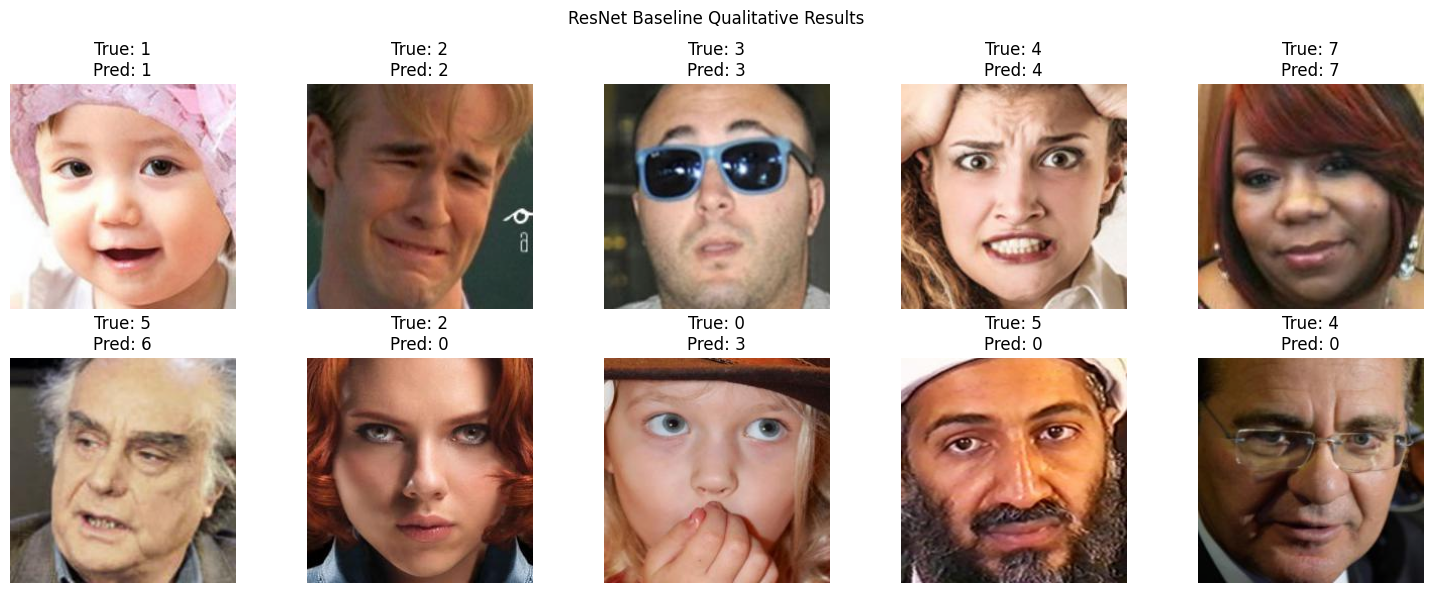

Qualitative Results for EfficientNet Baseline


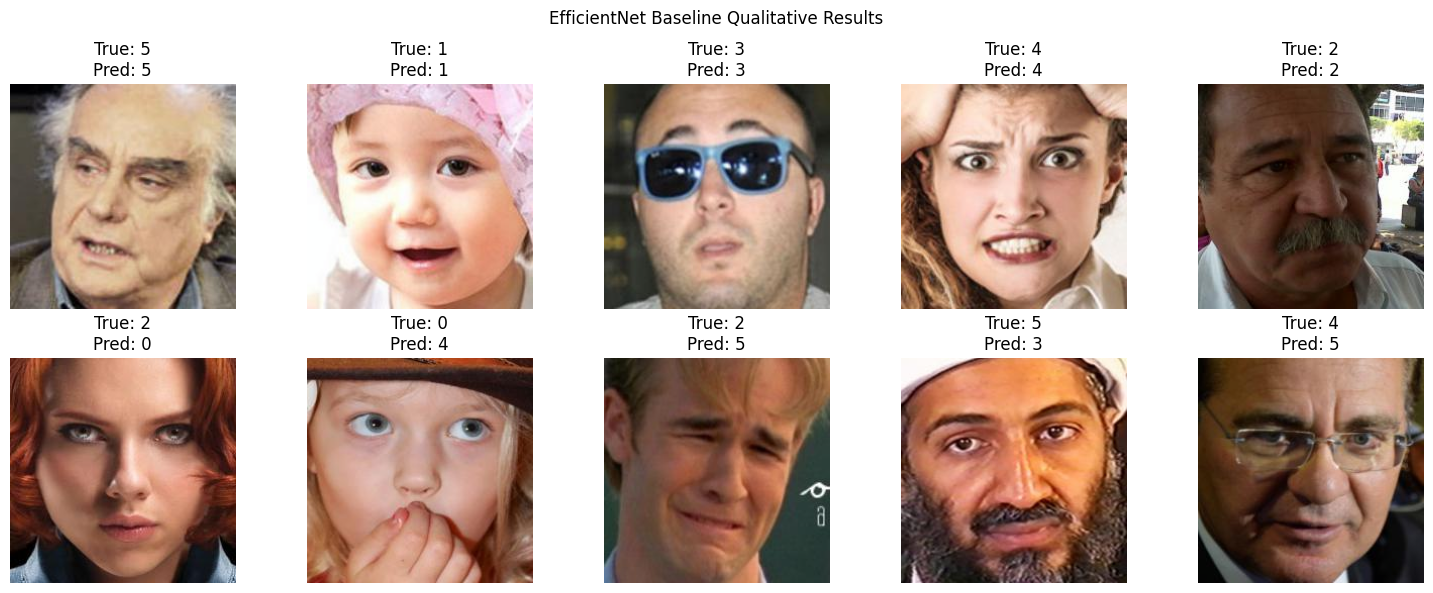

Qualitative Results for Ensemble


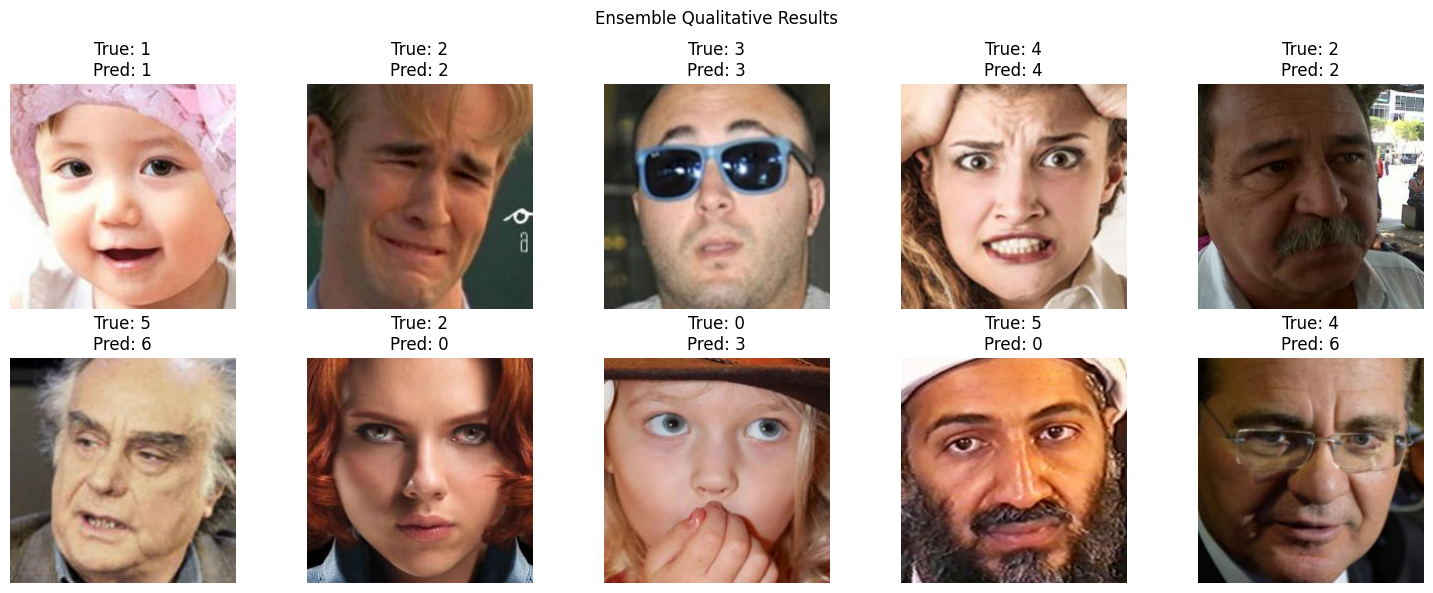

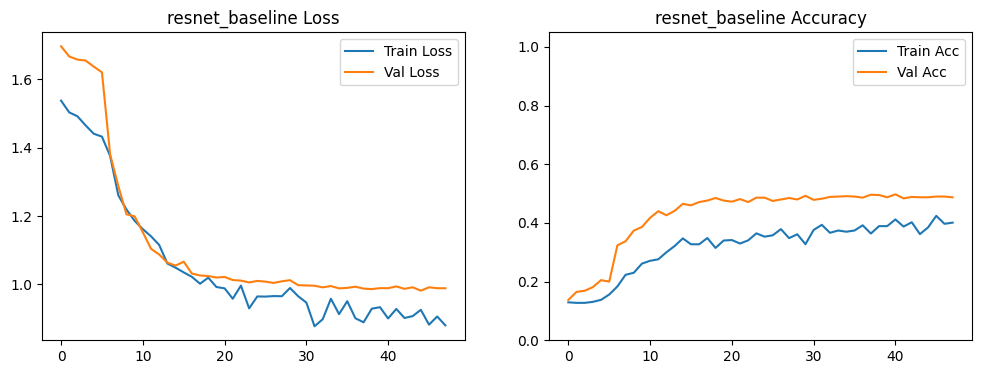

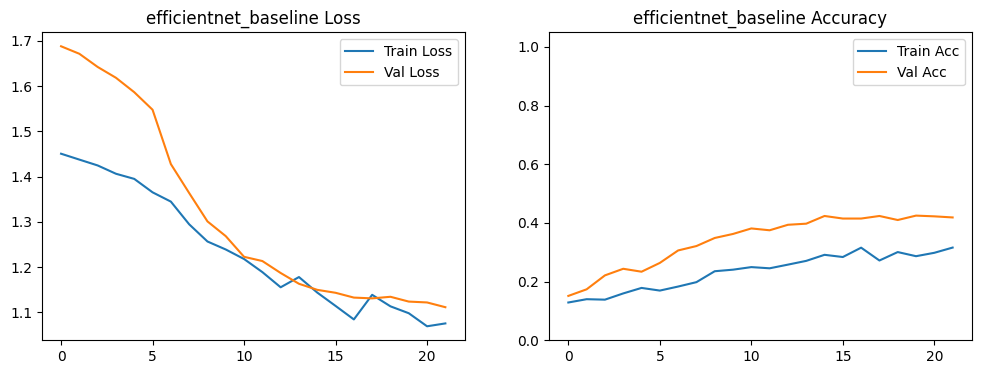


Updated Baseline Performance Comparison:
Model	Accuracy	F1	RMSE(Val)	RMSE(Aro)	CCC(Val)	CCC(Aro)	CORR(Val)	CORR(Aro)	SAGR(Val)	SAGR(Aro)
ResNet	0.4875	0.4925	0.3795	0.3472	0.4767	0.3365	0.6363	0.4734	0.5439	0.5699
EfficientNet	0.4188	0.4116	0.3955	0.3510	0.4558	0.3083	0.5969	0.4492	0.5098	0.5708
Ensemble	0.5025	0.5041	0.3833	0.3470	0.4475	0.3088	0.6496	0.4986	0.5298	0.5665


In [8]:
# Cell 5: Additional code for qualitative results, updated metrics (adding CORR and SAGR), training graphs (already handled, but ensure display), performance measures, discussion, and updated comparison

# First, update the evaluate_model function to include CORR and SAGR (modifying the existing function without disturbing previous logic)
def evaluate_model(model, loader, print_report=False):
    model.eval()
    criterion_cls = FocalLoss(gamma=2.0, reduction='none')
    criterion_reg = nn.SmoothL1Loss(reduction='none')
    
    all_labels = []
    all_preds = []
    all_va_true = []
    all_va_pred = []
    total_loss = 0.0
    
    with torch.no_grad():
        for images, labels, va in loader:
            images, labels, va = images.to(device), labels.to(device), va.to(device)
            cls_out, reg_out = model(images)
            loss_cls = criterion_cls(cls_out, labels).mean()
            loss_reg = criterion_reg(reg_out, va).mean()
            total_loss += (loss_cls + loss_reg).item()
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(cls_out.argmax(1).cpu().numpy())
            all_va_true.extend(va.cpu().numpy())
            all_va_pred.extend(reg_out.cpu().numpy())
    
    total_loss /= len(loader)
    
    # Categorical metrics
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    # Class-wise report
    if print_report:
        print("\nClass-wise Classification Report:")
        print(classification_report(all_labels, all_preds, digits=4))
        
        # Confusion matrix
        cm = confusion_matrix(all_labels, all_preds)
        print("\nConfusion Matrix:")
        print(cm)
        
        # Per-class recall
        per_class_recall = np.diag(cm) / np.sum(cm, axis=1)
        print("\nPer-Class Recall:")
        print(per_class_recall)
    
    # Continuous metrics
    va_true = np.array(all_va_true)
    va_pred = np.array(all_va_pred)
    rmse_val = np.sqrt(mean_squared_error(va_true[:,0], va_pred[:,0]))
    rmse_aro = np.sqrt(mean_squared_error(va_true[:,1], va_pred[:,1]))
    ccc_val = ConcordanceCC.compute(va_true[:,0], va_pred[:,0])
    ccc_aro = ConcordanceCC.compute(va_true[:,1], va_pred[:,1])
    corr_val, _ = pearsonr(va_true[:,0], va_pred[:,0])
    corr_aro, _ = pearsonr(va_true[:,1], va_pred[:,1])
    sagr_val = SignAgreementMetric.compute(va_true[:,0], va_pred[:,0])
    sagr_aro = SignAgreementMetric.compute(va_true[:,1], va_pred[:,1])
    
    metrics = {
        'total_loss': total_loss,
        'accuracy': accuracy,
        'f1_score': f1,
        'rmse_val': rmse_val,
        'rmse_aro': rmse_aro,
        'ccc_val': ccc_val,
        'ccc_aro': ccc_aro,
        'corr_val': corr_val,
        'corr_aro': corr_aro,
        'sagr_val': sagr_val,
        'sagr_aro': sagr_aro,
    }
    
    return metrics

# Update evaluate_ensemble to include CORR and SAGR
def evaluate_ensemble(resnet_model, effnet_model, loader):
    resnet_model.eval()
    effnet_model.eval()
    
    all_labels = []
    all_preds = []
    all_va_true = []
    all_va_pred = []
    
    with torch.no_grad():
        for images, labels, va in loader:
            images = images.to(device)
            labels, va = labels.to(device), va.to(device)
            
            tta_cls_r = []
            tta_reg_r = []
            tta_cls_e = []
            tta_reg_e = []
            for t in range(NUM_TTA):
                aug_images = apply_tta(images, t).to(device)
                cr, rr = resnet_model(aug_images)
                ce, re = effnet_model(aug_images)
                tta_cls_r.append(nn.Softmax(dim=1)(cr))
                tta_reg_r.append(rr)
                tta_cls_e.append(nn.Softmax(dim=1)(ce))
                tta_reg_e.append(re)
            
            cls_r = torch.mean(torch.stack(tta_cls_r), dim=0)
            reg_r = torch.mean(torch.stack(tta_reg_r), dim=0)
            cls_e = torch.mean(torch.stack(tta_cls_e), dim=0)
            reg_e = torch.mean(torch.stack(tta_reg_e), dim=0)
            
            # Weighted
            cls_out = (0.6 * cls_r + 0.4 * cls_e)
            reg_out = (0.6 * reg_r + 0.4 * reg_e)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(cls_out.argmax(1).cpu().numpy())
            all_va_true.extend(va.cpu().numpy())
            all_va_pred.extend(reg_out.cpu().numpy())
    
    # Compute metrics
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    va_true = np.array(all_va_true)
    va_pred = np.array(all_va_pred)
    rmse_val = np.sqrt(mean_squared_error(va_true[:,0], va_pred[:,0]))
    rmse_aro = np.sqrt(mean_squared_error(va_true[:,1], va_pred[:,1]))
    ccc_val = ConcordanceCC.compute(va_true[:,0], va_pred[:,0])
    ccc_aro = ConcordanceCC.compute(va_true[:,1], va_pred[:,1])
    corr_val, _ = pearsonr(va_true[:,0], va_pred[:,0])
    corr_aro, _ = pearsonr(va_true[:,1], va_pred[:,1])
    sagr_val = SignAgreementMetric.compute(va_true[:,0], va_pred[:,0])
    sagr_aro = SignAgreementMetric.compute(va_true[:,1], va_pred[:,1])
    
    metrics = {
        'accuracy': accuracy,
        'f1_score': f1,
        'rmse_val': rmse_val,
        'rmse_aro': rmse_aro,
        'ccc_val': ccc_val,
        'ccc_aro': ccc_aro,
        'corr_val': corr_val,
        'corr_aro': corr_aro,
        'sagr_val': sagr_val,
        'sagr_aro': sagr_aro,
    }
    
    print("\nEnsemble Classification Report:")
    print(classification_report(all_labels, all_preds, digits=4))
    
    return metrics

# Function for qualitative results (new)
def show_qualitative_results(model, loader, num_examples=5, title="Model"):
    if hasattr(model, 'eval'):
        model.eval()
    correct_examples = []
    incorrect_examples = []
    with torch.no_grad():
        for batch_images, batch_labels, _ in loader:
            batch_images_dev = batch_images.to(device)
            cls_out, _ = model(batch_images_dev)
            preds = cls_out.argmax(1).cpu().numpy()
            labels = batch_labels.numpy()
            
            for i in range(len(batch_labels)):
                orig_img = batch_images[i]  # Keep tensor for denorm
                if preds[i] == labels[i]:
                    if len(correct_examples) < num_examples:
                        correct_examples.append((orig_img, labels[i], preds[i]))
                else:
                    if len(incorrect_examples) < num_examples:
                        incorrect_examples.append((orig_img, labels[i], preds[i]))
                
                if len(correct_examples) >= num_examples and len(incorrect_examples) >= num_examples:
                    break
            if len(correct_examples) >= num_examples and len(incorrect_examples) >= num_examples:
                break
    
    # Denormalize function
    def denormalize(img_tensor):
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = img_tensor.permute(1, 2, 0).cpu().numpy()
        img = std * img + mean
        img = np.clip(img, 0, 1)
        return img
    
    # Plot
    fig, axs = plt.subplots(2, num_examples, figsize=(15, 6))
    fig.suptitle(f"{title} Qualitative Results")
    
    for i in range(num_examples):
        if i < len(correct_examples):
            img = denormalize(correct_examples[i][0])
            axs[0, i].imshow(img)
            axs[0, i].set_title(f"True: {correct_examples[i][1]}\nPred: {correct_examples[i][2]}")
            axs[0, i].axis('off')
    
    for i in range(num_examples):
        if i < len(incorrect_examples):
            img = denormalize(incorrect_examples[i][0])
            axs[1, i].imshow(img)
            axs[1, i].set_title(f"True: {incorrect_examples[i][1]}\nPred: {incorrect_examples[i][2]}")
            axs[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Update plot_history to show plots in addition to saving (if not already showing)
def plot_history(history, model_name):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title(f'{model_name} Loss')
    
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.ylim(0, 1.05)
    plt.legend()
    plt.title(f'{model_name} Accuracy')
    plt.savefig(f'{model_name}_training_plots.png')
    plt.show()  # Add show to display in notebook
    plt.close()

# Re-evaluate baselines with updated metrics (since we modified evaluate_model)
print("Re-evaluating ResNet Baseline with updated metrics")
resnet_metrics_base = evaluate_model(resnet_baseline, val_loader, print_report=True)

print("Re-evaluating EfficientNet Baseline with updated metrics")
effnet_metrics_base = evaluate_model(effnet_baseline, val_loader, print_report=True)

# Re-evaluate ensemble with updated metrics
ensemble_metrics_base = evaluate_ensemble(resnet_baseline, effnet_baseline, val_loader)

# Show qualitative results for each model
print("Qualitative Results for ResNet Baseline")
show_qualitative_results(resnet_baseline, val_loader, title="ResNet Baseline")

print("Qualitative Results for EfficientNet Baseline")
show_qualitative_results(effnet_baseline, val_loader, title="EfficientNet Baseline")

# For ensemble, create a wrapper function since ensemble uses two models
def ensemble_forward(images):
    images = images.to(device)
    with torch.no_grad():
        tta_cls_r = []
        tta_reg_r = []
        tta_cls_e = []
        tta_reg_e = []
        for t in range(NUM_TTA):
            aug_images = apply_tta(images, t).to(device)
            cr, rr = resnet_baseline(aug_images)
            ce, re = effnet_baseline(aug_images)
            tta_cls_r.append(nn.Softmax(dim=1)(cr))
            tta_reg_r.append(rr)
            tta_cls_e.append(nn.Softmax(dim=1)(ce))
            tta_reg_e.append(re)
        
        cls_r = torch.mean(torch.stack(tta_cls_r), dim=0)
        reg_r = torch.mean(torch.stack(tta_reg_r), dim=0)
        cls_e = torch.mean(torch.stack(tta_cls_e), dim=0)
        reg_e = torch.mean(torch.stack(tta_reg_e), dim=0)
        
        cls_out = (0.6 * cls_r + 0.4 * cls_e)
        reg_out = (0.6 * reg_r + 0.4 * reg_e)
    return cls_out, reg_out

print("Qualitative Results for Ensemble")
show_qualitative_results(ensemble_forward, val_loader, title="Ensemble")

# Re-plot histories to show them (already saved, but show again if needed)
plot_history(resnet_history_base, "resnet_baseline")
plot_history(effnet_history_base, "efficientnet_baseline")

# Updated baseline comparison with all metrics
print("\nUpdated Baseline Performance Comparison:")
print("Model\tAccuracy\tF1\tRMSE(Val)\tRMSE(Aro)\tCCC(Val)\tCCC(Aro)\tCORR(Val)\tCORR(Aro)\tSAGR(Val)\tSAGR(Aro)")
print(f"ResNet\t{resnet_metrics_base['accuracy']:.4f}\t{resnet_metrics_base['f1_score']:.4f}\t{resnet_metrics_base['rmse_val']:.4f}\t{resnet_metrics_base['rmse_aro']:.4f}\t{resnet_metrics_base['ccc_val']:.4f}\t{resnet_metrics_base['ccc_aro']:.4f}\t{resnet_metrics_base['corr_val']:.4f}\t{resnet_metrics_base['corr_aro']:.4f}\t{resnet_metrics_base['sagr_val']:.4f}\t{resnet_metrics_base['sagr_aro']:.4f}")
print(f"EfficientNet\t{effnet_metrics_base['accuracy']:.4f}\t{effnet_metrics_base['f1_score']:.4f}\t{effnet_metrics_base['rmse_val']:.4f}\t{effnet_metrics_base['rmse_aro']:.4f}\t{effnet_metrics_base['ccc_val']:.4f}\t{effnet_metrics_base['ccc_aro']:.4f}\t{effnet_metrics_base['corr_val']:.4f}\t{effnet_metrics_base['corr_aro']:.4f}\t{effnet_metrics_base['sagr_val']:.4f}\t{effnet_metrics_base['sagr_aro']:.4f}")
print(f"Ensemble\t{ensemble_metrics_base['accuracy']:.4f}\t{ensemble_metrics_base['f1_score']:.4f}\t{ensemble_metrics_base['rmse_val']:.4f}\t{ensemble_metrics_base['rmse_aro']:.4f}\t{ensemble_metrics_base['ccc_val']:.4f}\t{ensemble_metrics_base['ccc_aro']:.4f}\t{ensemble_metrics_base['corr_val']:.4f}\t{ensemble_metrics_base['corr_aro']:.4f}\t{ensemble_metrics_base['sagr_val']:.4f}\t{ensemble_metrics_base['sagr_aro']:.4f}")